In [1]:
# =========================================================
# DBSCAN CLusteing Model
# =========================================================

# 1. IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

In [2]:
# =========================================================
# 2. LOAD DATASET
# =========================================================

df = pd.read_csv("Mall_Customers.csv")

print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [3]:
# =========================================================
# 3. SELECT IMPORTANT FEATURES
# =========================================================
# Using customer behavior features

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]


# =========================================================
# 4. FEATURE SCALING
# =========================================================
# Important for distance/probability calculations

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [8]:
type(X)

pandas.core.frame.DataFrame

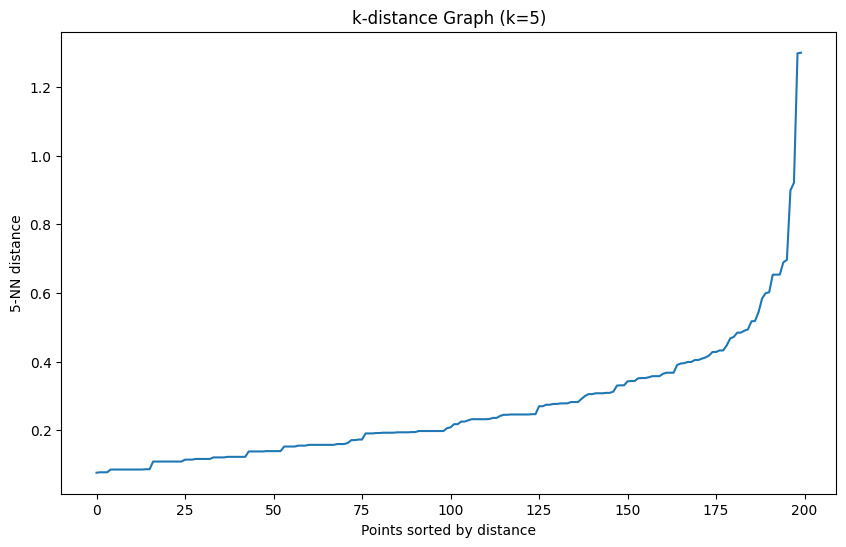

In [17]:
# =========================================================
# 4. Finding the Eplsilon values
# =========================================================
from sklearn.neighbors import NearestNeighbors
import numpy as np
min_samples=5
neigh = NearestNeighbors(n_neighbors=min_samples)
neigh.fit(X_scaled)

distance, indices = neigh.kneighbors(X_scaled)
#print(type(distance))
#print(distance)
#print(indices)
k_distance = np.sort(distance[:, min_samples-1])
plt.figure(figsize=(10,6))
plt.plot(k_distance)
plt.title(f"k-distance Graph (k={min_samples})")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}-NN distance")
plt.show()

In [20]:
# =========================================================
# 5. TRAIN DBSCAN MODEL
# =========================================================
#From the above grapth we get to know sharp curve starts from between 0.5 to 0.6, Hence Eps score is calculated as 0.5
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(
    eps=0.5,          # Neighborhood radius
    min_samples=5,    # Minimum points required
    metric='euclidean'
)

clusters = dbscan.fit_predict(X_scaled)

In [21]:
# =========================================================
# 6. ADD CLUSTER LABELS
# =========================================================

df['Cluster'] = clusters


# =========================================================
# 7. CHECK UNIQUE CLUSTERS
# =========================================================

print("\nUnique Cluster Labels:")
print(np.unique(clusters))


# =========================================================
# 8. COUNT CLUSTERS
# =========================================================

print("\nCluster Counts:")
print(df['Cluster'].value_counts())


# =========================================================
# 9. IDENTIFY NOISE POINTS
# =========================================================
# DBSCAN marks outliers as -1

noise_points = df[df['Cluster'] == -1]

print("\nNumber of Noise Points:", len(noise_points))




Unique Cluster Labels:
[-1  0  1]

Cluster Counts:
Cluster
 0    157
 1     35
-1      8
Name: count, dtype: int64

Number of Noise Points: 8


In [22]:
# =========================================================
# 10. EVALUATE MODEL
# =========================================================
# Silhouette score only if more than 1 cluster exists

mask = clusters != -1
if len(set(clusters[mask])) > 1:   # need at least 2 clusters
    score = silhouette_score(X_scaled[mask], clusters[mask])
    print("Silhouette Score:", score)
else:
    print("Silhouette Score cannot be computed (only one cluster found).")

Silhouette Score: 0.3875583892728279


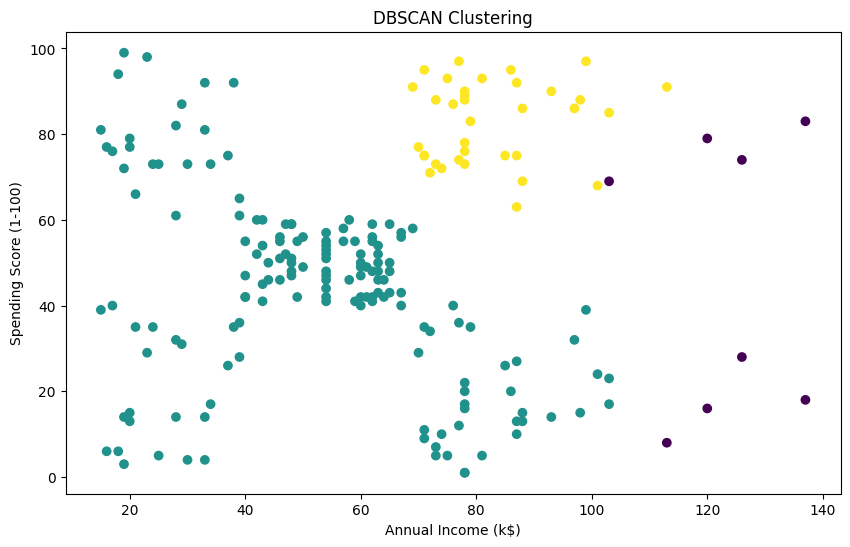

In [23]:
# =========================================================
# 11. VISUALIZE CLUSTERS
# =========================================================

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster']
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("DBSCAN Clustering")

plt.show()

In [24]:
# =========================================================
# 12. SAVE OUTPUT
# =========================================================

df.to_csv("Mall_Customers_DBSCAN_Clustered.csv", index=False)

print("\nClustered dataset saved successfully.")


Clustered dataset saved successfully.
